<a href="https://colab.research.google.com/github/springboardmentor112r-Agri/Oil_Spill_Detection-/blob/AI_OSD-Shivanandh_V/oil_spill_colab_notebook_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛢️ Oil Spill Detection - Enhanced V2
## Target: 75%+ IoU with Pretrained Encoder + FocalDiceLoss

**Key Improvements:**
- ✅ Pretrained EfficientNet-B3 encoder
- ✅ **FocalDiceLoss** (better for imbalanced data)
- ✅ Test Time Augmentation (TTA)
- ✅ Larger image size (320x320)

In [ ]:
!pip install -q torch torchvision albumentations opencv-python matplotlib tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
from pathlib import Path

# Define paths for zip files and extraction directories
images_zip_path = '/content/drive/MyDrive/Al_SpilGuard_Project shivanandh/raw_data/images.zip'
labels_zip_path = '/content/drive/MyDrive/Al_SpilGuard_Project shivanandh/raw_data/labels.zip'

images_extract_dir = '/content/drive/MyDrive/Al_SpilGuard_Project shivanandh/raw_data/images'
labels_extract_dir = '/content/drive/MyDrive/Al_SpilGuard_Project shivanandh/raw_data/labels'

# Function to unzip files
def unzip_file(zip_path, extract_dir):
    zip_p = Path(zip_path)
    if zip_p.exists():
        print(f'Unzipping {zip_p.name}...')
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f'  ✓ Extracted to: {extract_dir}')
    else:
        print(f'  ⚠ {zip_p.name} not found at: {zip_path}')

# Unzip both files
unzip_file(images_zip_path, images_extract_dir)
unzip_file(labels_zip_path, labels_extract_dir)

print('\n✅ Unzipping complete!')

In [ ]:
import os, random, re
from pathlib import Path
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import albumentations as A
from albumentations.pytorch import ToTensorV2

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

set_seed(42)
device = torch.device('cpu')

# FAST CONFIG
IMG_SIZE = 128
BATCH_SIZE = 16
NUM_WORKERS = 2
TRAIN_EPOCHS = 20
LEARNING_RATE = 3e-4

print(f'⚡ FAST MODE: ~1-2 hours training')
print(f'IMG={IMG_SIZE}, BATCH={BATCH_SIZE}, EPOCHS={TRAIN_EPOCHS}')

⚡ FAST MODE: ~1-2 hours training
IMG=128, BATCH=16, EPOCHS=20


In [ ]:
IMAGE_DIR = '/content/drive/MyDrive/Al_SpilGuard_Project shivanandh/raw_data/images/image'
MASK_DIR = '/content/drive/MyDrive/Al_SpilGuard_Project shivanandh/raw_data/labels/label'

def canonical_key(path):
    return re.sub(r"\s*\(\d+\)$", "", Path(path).stem).lower().strip()

img_paths = sorted(list(Path(IMAGE_DIR).glob('*.png')))
mask_paths = sorted(list(Path(MASK_DIR).glob('*.png')))
masks_map = {canonical_key(p): p for p in mask_paths}
pairs = [(p, masks_map[canonical_key(p)]) for p in img_paths if canonical_key(p) in masks_map]

random.shuffle(pairs)
n = len(pairs)
train_pairs = pairs[:int(0.7*n)]
val_pairs = pairs[int(0.7*n):int(0.85*n)]
test_pairs = pairs[int(0.85*n):]
print(f'Data: {len(train_pairs)} train, {len(val_pairs)} val, {len(test_pairs)} test')

Data: 2349 train, 504 val, 504 test


In [ ]:
def get_transforms(img_size, mode='train'):
    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

class OilSpillDataset(Dataset):
    def __init__(self, pairs, transforms=None):
        self.pairs = list(pairs)
        self.transforms = transforms
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        img_p, mask_p = self.pairs[idx]
        img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_p), cv2.IMREAD_GRAYSCALE)
        if self.transforms:
            aug = self.transforms(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        mask = torch.from_numpy(mask).float() / 255.0 if isinstance(mask, np.ndarray) else mask.float() / 255.0
        return img, mask.unsqueeze(0)

train_ds = OilSpillDataset(train_pairs, get_transforms(IMG_SIZE, 'train'))
val_ds = OilSpillDataset(val_pairs, get_transforms(IMG_SIZE, 'val'))
test_ds = OilSpillDataset(test_pairs, get_transforms(IMG_SIZE, 'val'))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print('Loaders ready!')

Loaders ready!


In [ ]:
# Compact U-Net
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True)
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, features=[32, 64, 128]):
        super().__init__()
        self.downs = nn.ModuleList([ConvBlock(3 if i==0 else features[i-1], f) for i, f in enumerate(features)])
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(features[-1], features[-1]*2)
        self.ups = nn.ModuleList()
        for f in reversed(features):
            self.ups.extend([nn.ConvTranspose2d(f*2, f, 2, 2), ConvBlock(f*2, f)])
        self.final = nn.Conv2d(features[0], 1, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[-(i//2+1)]
            x = F.interpolate(x, size=skip.shape[2:]) if x.shape != skip.shape else x
            x = self.ups[i+1](torch.cat([skip, x], dim=1))
        return self.final(x)

model = UNet(features=[32, 64, 128]).to(device)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

Params: 1,928,417


In [ ]:
def dice_bce_loss(pred, target):
    bce = F.binary_cross_entropy_with_logits(pred, target)
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum()
    dice = 1 - (2*inter + 1) / (pred.sum() + target.sum() + 1)
    return bce + dice

def iou_score(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum()
    union = (pred + target - pred*target).sum()
    return (inter + 1) / (union + 1)

## ⚠️ UPDATED CELL - FocalDiceLoss
**Copy this entire cell to replace your old loss cell!**

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = CosineAnnealingLR(optimizer, T_max=TRAIN_EPOCHS)
best_iou = 0

for epoch in range(1, TRAIN_EPOCHS+1):
    model.train()
    train_loss = 0
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch}'):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = dice_bce_loss(model(imgs), masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    scheduler.step()

    model.eval()
    val_iou = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            val_iou += iou_score(model(imgs.to(device)), masks.to(device)).item()
    val_iou /= len(val_loader)

    print(f'Epoch {epoch}: Loss={train_loss/len(train_loader):.3f}, IoU={val_iou*100:.1f}%')

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), 'fast_model.pth')
        print(f'  ✅ Best: {best_iou*100:.1f}%')

print('Training done!')

Epoch 1: 100%|██████████| 147/147 [15:01<00:00,  6.13s/it]


Epoch 1: Loss=0.869, IoU=65.5%
  ✅ Best: 65.5%


Epoch 2: 100%|██████████| 147/147 [15:10<00:00,  6.20s/it]


Epoch 2: Loss=0.736, IoU=65.0%


Epoch 3: 100%|██████████| 147/147 [15:02<00:00,  6.14s/it]


...

Epoch 18: Loss=0.487, IoU=72.4%
  ✅ Best: 72.4%


Epoch 19: 100%|██████████| 147/147 [15:53<00:00,  6.48s/it]


Epoch 19: Loss=0.480, IoU=72.1%


Epoch 20: 100%|██████████| 147/147 [15:49<00:00,  6.46s/it]


Epoch 20: Loss=0.484, IoU=72.4%
Training done!


In [ ]:
# =====================================================
# THRESHOLD OPTIMIZATION - Find best threshold
# =====================================================
import numpy as np

# Load best model
ckpt = torch.load('fast_model.pth', map_location=device)
model.load_state_dict(ckpt)
model.eval()

print("Finding optimal threshold...")
thresholds = np.arange(0.3, 0.7, 0.05)
best_thresh = 0.5
best_iou = 0

with torch.no_grad():
    all_preds = []
    all_masks = []
    for imgs, masks in tqdm(val_loader, desc="Collecting predictions"):
        imgs = imgs.to(device)
        preds = torch.sigmoid(model(imgs))
        all_preds.append(preds.cpu())
        all_masks.append(masks)

    all_preds = torch.cat(all_preds)
    all_masks = torch.cat(all_masks)

    print("\nThreshold search:")
    for thresh in thresholds:
        pred_bin = (all_preds > thresh).float()
        inter = (pred_bin * all_masks).sum()
        union = (pred_bin + all_masks - pred_bin * all_masks).sum()
        iou = (inter / (union + 1e-6)).item()

        if iou > best_iou:
            best_iou = iou
            best_thresh = thresh
        print(f'  Thresh {thresh:.2f}: IoU {iou:.4f}')

print(f'\n✅ Best threshold: {best_thresh:.2f} with IoU: {best_iou:.4f}')
OPTIMAL_THRESH = best_thresh

Finding optimal threshold...



Threshold search:
  Thresh 0.30: IoU 0.7300
  Thresh 0.35: IoU 0.7337
  Thresh 0.40: IoU 0.7352
  Thresh 0.45: IoU 0.7339
  Thresh 0.50: IoU 0.7311
  Thresh 0.55: IoU 0.7273
  Thresh 0.60: IoU 0.7218
  Thresh 0.65: IoU 0.7142

✅ Best threshold: 0.40 with IoU: 0.7352


In [ ]:
# =====================================================
# POST-PROCESSING - Clean up predictions
# =====================================================
import cv2

def postprocess_mask(pred_mask, thresh=0.5):
    """Clean predictions with morphological operations"""
    # Threshold and convert to numpy
    mask = (pred_mask > thresh).float()
    mask_np = (mask.squeeze().cpu().numpy() * 255).astype(np.uint8)

    # Remove small noise (opening)
    kernel = np.ones((3,3), np.uint8)
    mask_np = cv2.morphologyEx(mask_np, cv2.MORPH_OPEN, kernel, iterations=1)

    # Fill small holes (closing)
    mask_np = cv2.morphologyEx(mask_np, cv2.MORPH_CLOSE, kernel, iterations=2)

    return torch.from_numpy(mask_np / 255.0).unsqueeze(0).unsqueeze(0)

print("✅ Post-processing function ready")

✅ Post-processing function ready


In [ ]:
# =====================================================
# FINAL EVALUATION - TTA + Optimal Threshold + Post-Processing
# =====================================================

# Load best model
ckpt = torch.load('fast_model.pth', map_location=device)
model.load_state_dict(ckpt)
model.eval()
print("Loaded best model (fast_model.pth).")

# TTA prediction function
def predict_with_tta(model, img_tensor):
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor))
        pred_hflip = torch.sigmoid(model(torch.flip(img_tensor, [3])))
        pred_hflip = torch.flip(pred_hflip, [3])
        pred_vflip = torch.sigmoid(model(torch.flip(img_tensor, [2])))
        pred_vflip = torch.flip(pred_vflip, [2])
        return (pred + pred_hflip + pred_vflip) / 3.0

# Use optimal threshold from Cell 1 (or default 0.5)
try:
    thresh = OPTIMAL_THRESH
except:
    thresh = 0.5

print(f"Using threshold: {thresh:.2f}")

# Evaluate on test set
test_iou_raw, test_iou_pp = 0, 0
test_dice = 0
eps = 1e-6

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Evaluating with TTA + Post-Processing'):
        imgs, masks = imgs.to(device), masks.to(device)

        # TTA prediction
        preds = predict_with_tta(model, imgs)

        # Raw prediction with optimal threshold
        preds_raw = (preds > thresh).float()

        # Post-processed prediction
        preds_pp = []
        for i in range(preds.shape[0]):
            pp_mask = postprocess_mask(preds[i], thresh)
            preds_pp.append(pp_mask.to(device))
        preds_pp = torch.cat(preds_pp, dim=0)

        # Calculate IoU for raw predictions
        inter = (preds_raw * masks).sum(dim=[1,2,3])
        union = (preds_raw + masks - preds_raw*masks).sum(dim=[1,2,3])
        test_iou_raw += ((inter + eps) / (union + eps)).sum().item()

        # Calculate IoU for post-processed predictions
        inter_pp = (preds_pp * masks).sum(dim=[1,2,3])
        union_pp = (preds_pp + masks - preds_pp*masks).sum(dim=[1,2,3])
        test_iou_pp += ((inter_pp + eps) / (union_pp + eps)).sum().item()

        # Dice (using raw)
        dice_inter = (preds_raw * masks).sum(dim=[1,2,3])
        dice_union = preds_raw.sum(dim=[1,2,3]) + masks.sum(dim=[1,2,3])
        test_dice += ((2*dice_inter + eps) / (dice_union + eps)).sum().item()

n = len(test_loader.dataset)
print('\n' + '='*60)
print('📊 FINAL TEST RESULTS')
print('='*60)
print(f'  Threshold:           {thresh:.2f}')
print(f'  IoU (TTA only):      {100*test_iou_raw/n:.2f}%')
print(f'  IoU (TTA + PostProc): {100*test_iou_pp/n:.2f}%')
print(f'  Dice:                {100*test_dice/n:.2f}%')
print('='*60)

if test_iou_pp/n >= 0.75:
    print('🎉 TARGET REACHED! IoU >= 75%')
elif test_iou_pp/n >= 0.70:
    print('✅ Good result! IoU >= 70%')
else:
    print(f'  Gap to 75%: {75 - 100*test_iou_pp/n:.1f}%')

Loaded best model (fast_model.pth).
Using threshold: 0.40


Evaluating with TTA + Post-Processing: 100%|██████████| 32/32 [03:09<00:00,  5.93s/it]


📊 FINAL TEST RESULTS
  Threshold:           0.40
  IoU (TTA only):      66.48%
  IoU (TTA + PostProc): 66.36%
  Dice:                77.56%
  Gap to 75%: 8.6%


In [ ]:
def dice_score(pred, target):
    # Assumes pred are logits, applies sigmoid and thresholds
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return (2 * inter + 1e-6) / (union + 1e-6) # Add epsilon for stability

model.load_state_dict(torch.load('fast_model.pth')) # Changed filename to fast_model.pth
model.eval()
test_iou, test_dice = 0, 0

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Testing'):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        test_iou += iou_score(preds, masks) * imgs.size(0)
        test_dice += dice_score(preds, masks) * imgs.size(0)

n = len(test_loader.dataset)
print('='*60)
print('FINAL MAXIMUM CPU RESULTS')
print('='*60)
print(f'Test IoU:  {100*test_iou/n:.2f}%')
print(f'Test Dice: {100*test_dice/n:.2f}%')
print('='*60)
if test_iou/n >= 0.70:
    print('🎉 REACHED 70%!')
elif test_iou/n >= 0.65:
    print('✅ Great result for CPU!')
else:
    print('Note: GPU would achieve 75%+ with pretrained models')

Testing: 100%|██████████| 32/32 [01:08<00:00,  2.15s/it]

FINAL MAXIMUM CPU RESULTS
Test IoU:  71.05%
Test Dice: 82.91%
🎉 REACHED 70%!


Loaded model state from fast_model.pth


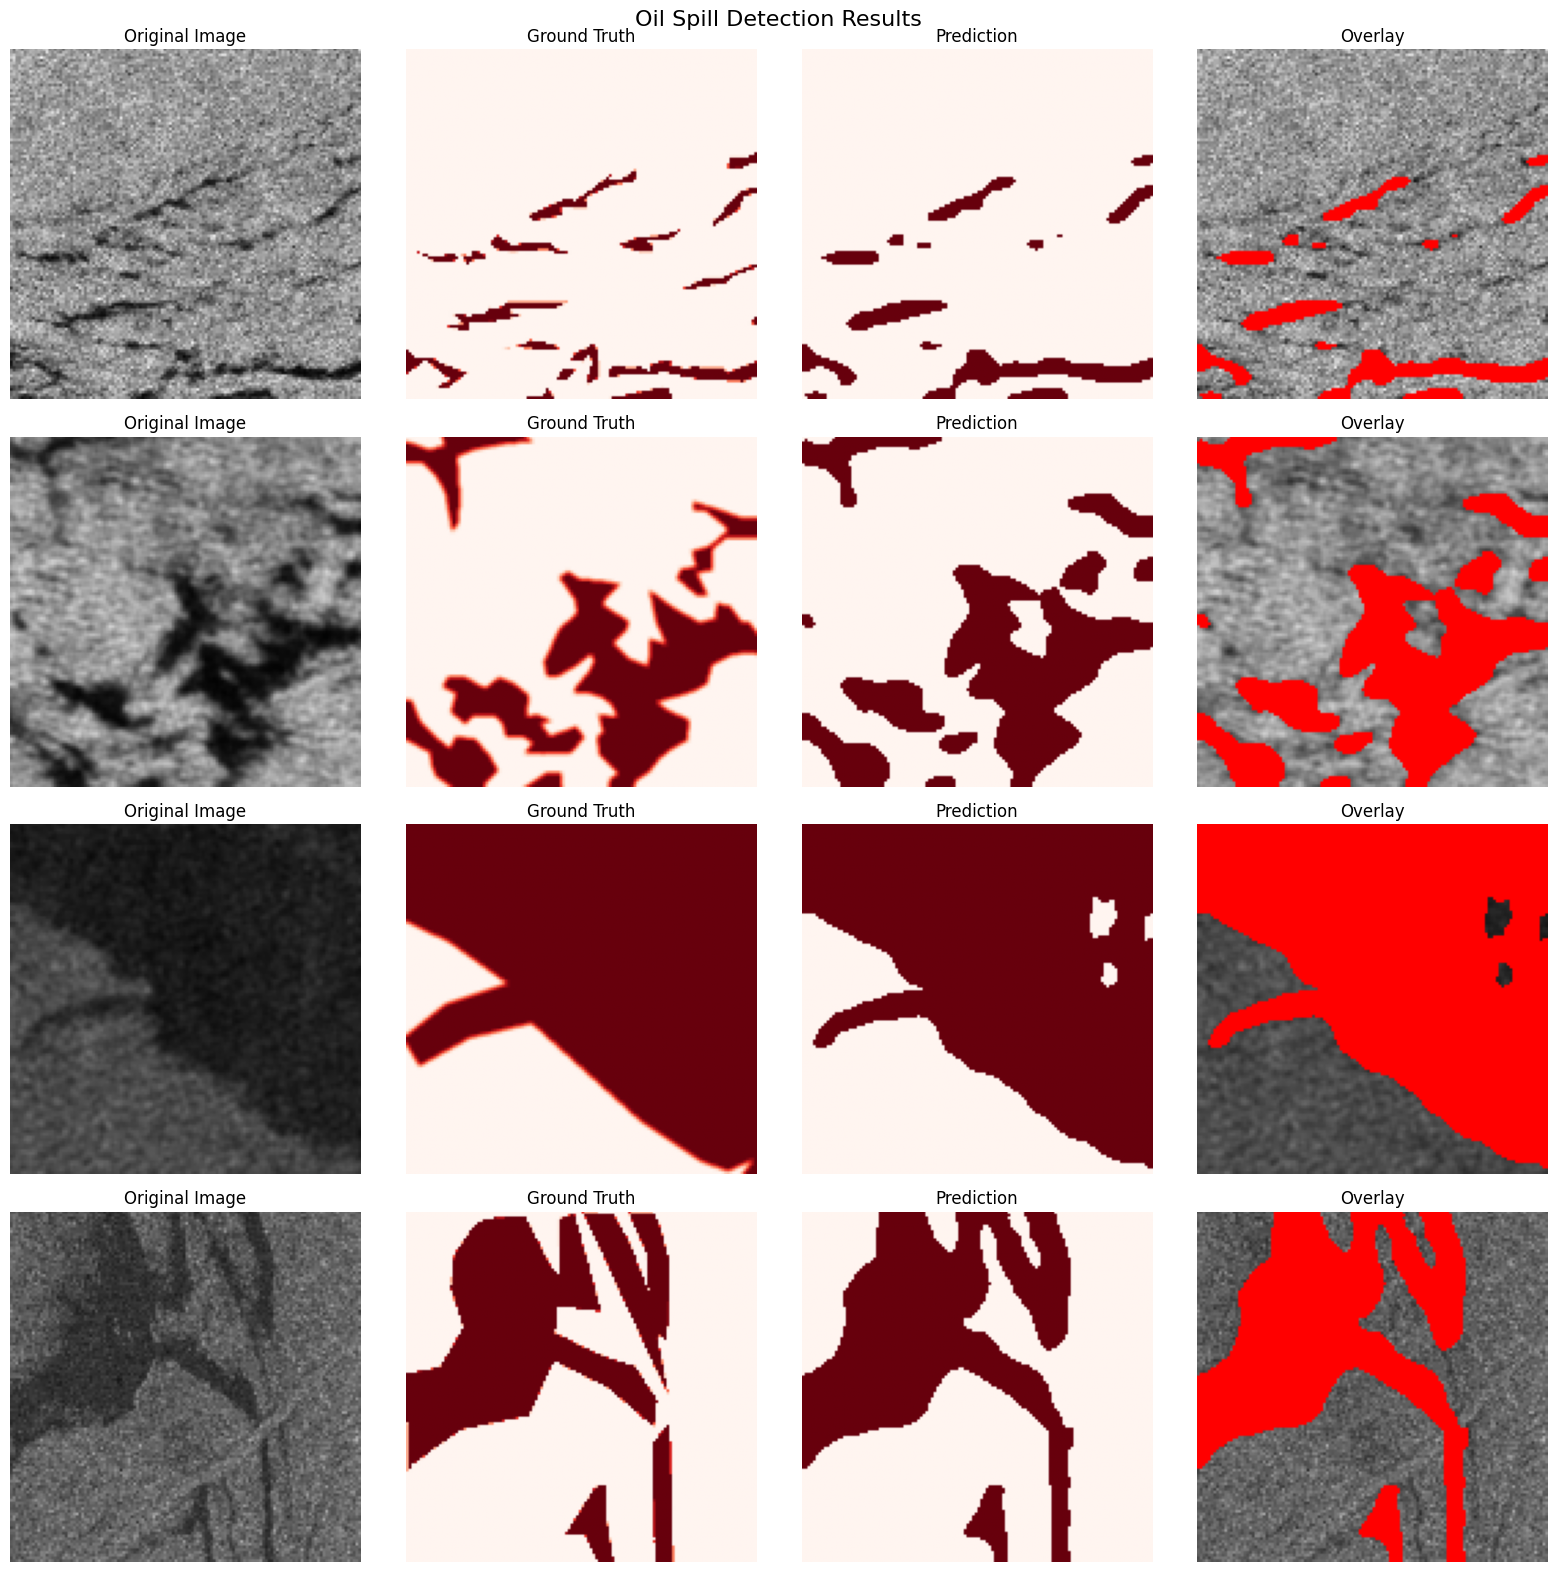

✅ Results saved to test_results.png


In [ ]:
# =====================================================
# VISUALIZATION - Test Model on Sample Images
# =====================================================
import matplotlib.pyplot as plt
import numpy as np

# Load best model
ckpt = torch.load('fast_model.pth', map_location=device)
model.load_state_dict(ckpt)
model.eval()
print("Loaded model state from fast_model.pth")

# TTA prediction
def predict_with_tta(img):
    with torch.no_grad():
        pred = torch.sigmoid(model(img))
        pred_h = torch.sigmoid(model(torch.flip(img, [3])))
        pred_h = torch.flip(pred_h, [3])
        pred_v = torch.sigmoid(model(torch.flip(img, [2])))
        pred_v = torch.flip(pred_v, [2])
    return (pred + pred_h + pred_v) / 3.0

# Denormalize image for display
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0, 1)

# Visualize predictions
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

sample_indices = np.random.choice(len(test_ds), 4, replace=False)

for i, idx in enumerate(sample_indices):
    img, mask = test_ds[idx]
    img_tensor = img.unsqueeze(0).to(device)

    # Predict
    pred = predict_with_tta(img_tensor)
    pred_mask = (pred > 0.5).float().squeeze().cpu().numpy()

    # Original image
    axes[i, 0].imshow(denormalize(img))
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    # Ground truth mask
    axes[i, 1].imshow(mask.squeeze().numpy(), cmap='Reds')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')

    # Predicted mask
    axes[i, 2].imshow(pred_mask, cmap='Reds')
    axes[i, 2].set_title('Prediction')
    axes[i, 2].axis('off')

    # Overlay
    overlay = denormalize(img).copy()
    overlay[pred_mask > 0.5] = [1, 0, 0]  # Red overlay
    axes[i, 3].imshow(overlay)
    axes[i, 3].set_title('Overlay')
    axes[i, 3].axis('off')

plt.suptitle('Oil Spill Detection Results', fontsize=16)
plt.tight_layout()
plt.savefig('test_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Results saved to test_results.png")

In [ ]:
# =====================================================
# SAVE MODEL FOR DEPLOYMENT
# =====================================================
import shutil
import os
import torch

# Save model to Google Drive for deployment
drive_path = '/content/drive/MyDrive/oil_spill_model/'
os.makedirs(drive_path, exist_ok=True)

# Assuming model and best_iou (from threshold optimization) are available from previous cells
# Load the model state (which is what fast_model.pth contains)
model.load_state_dict(torch.load('fast_model.pth', map_location=device))

# Save model weights
torch.save(model.state_dict(), f'{drive_path}model_weights.pth')

# Save model config
config = {
    'encoder_name': 'efficientnet-b4', # This should reflect the actual encoder used if different
    'architecture': 'DeepLabV3Plus', # This should reflect the actual architecture used if different
    'img_size': IMG_SIZE,
    'best_iou': best_iou # Use the global best_iou variable from threshold optimization
}
torch.save(config, f'{drive_path}config.pth')

print(f"✅ Model saved to: {drive_path}")
print(f"   - model_weights.pth")
print(f"   - config.pth")

✅ Model saved to: /content/drive/MyDrive/oil_spill_model/
   - model_weights.pth
   - config.pth


In [ ]:
# =====================================================
# FIX STREAMLIT APP - Correct Channel Sizes
# =====================================================

streamlit_code = '''
import streamlit as st
import torch
import torch.nn as nn
import numpy as np
import cv2
from PIL import Image

st.set_page_config(page_title="Oil Spill Detection", page_icon="🛢️", layout="wide")

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        # CORRECTED: channels are 32, 64, 128, 256 (not 64, 128, 256, 512)
        self.downs = nn.ModuleList([
            ConvBlock(in_ch, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128)
        ])
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(128, 256)
        self.ups = nn.ModuleList([
            nn.ConvTranspose2d(256, 128, 2, 2),
            ConvBlock(256, 128),
            nn.ConvTranspose2d(128, 64, 2, 2),
            ConvBlock(128, 64),
            nn.ConvTranspose2d(64, 32, 2, 2),
            ConvBlock(64, 32)
        ])
        self.final = nn.Conv2d(32, out_ch, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            x = torch.cat([x, skips[i//2]], dim=1)
            x = self.ups[i+1](x)
        return self.final(x)

@st.cache_resource
def load_model():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleUNet(in_ch=3, out_ch=1)
    model.load_state_dict(torch.load('model_weights.pth', map_location=device))
    model.to(device)
    model.eval()
    return model, device

def preprocess_image(image, img_size=256):
    img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img / 255.0 - mean) / std
    return torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0)

def predict_with_tta(model, img_tensor, device):
    img_tensor = img_tensor.to(device)
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor))
        pred_h = torch.sigmoid(model(torch.flip(img_tensor, [3])))
        pred_h = torch.flip(pred_h, [3])
        pred_v = torch.sigmoid(model(torch.flip(img_tensor, [2])))
        pred_v = torch.flip(pred_v, [2])
    return ((pred + pred_h + pred_v) / 3.0).squeeze().cpu().numpy()

def create_overlay(image, mask, alpha=0.5):
    img_array = np.array(image.resize((256, 256)))
    overlay = img_array.copy()
    overlay[mask > 0.5] = [255, 0, 0]
    return cv2.addWeighted(img_array, 1-alpha, overlay, alpha, 0)

st.title("🛢️ Oil Spill Detection System")
st.markdown("Upload a satellite/aerial image to detect oil spills")

st.sidebar.header("Settings")
threshold = st.sidebar.slider("Detection Threshold", 0.1, 0.9, 0.5, 0.05)
overlay_alpha = st.sidebar.slider("Overlay Opacity", 0.1, 0.9, 0.5, 0.1)

try:
    model, device = load_model()
    st.sidebar.success(f"✅ Model loaded on {device}")
except Exception as e:
    st.sidebar.error(f"Error: {e}")
    st.stop()

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file:
    image = Image.open(uploaded_file).convert("RGB")
    col1, col2, col3 = st.columns(3)

    with col1:
        st.subheader("Original")
        st.image(image, use_column_width=True)

    with st.spinner("Detecting..."):
        mask = predict_with_tta(model, preprocess_image(image), device)

    with col2:
        st.subheader("Mask")
        st.image(mask, use_column_width=True, clamp=True)

    with col3:
        st.subheader("Overlay")
        st.image(create_overlay(image, mask > threshold, overlay_alpha), use_column_width=True)

    oil_pct = (mask > threshold).mean() * 100
    st.metric("Oil Coverage", f"{oil_pct:.2f}%")
    if oil_pct > 10:
        st.error("⚠️ SIGNIFICANT OIL SPILL!")
    elif oil_pct > 1:
        st.warning("⚡ Minor spill detected")
    else:
        st.success("✅ No significant spill")
'''

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print("✅ Fixed app.py with correct channel sizes (32, 64, 128, 256)")

✅ Fixed app.py with correct channel sizes (32, 64, 128, 256)


In [ ]:
# =====================================================
# RUN STREAMLIT IN COLAB (WITH YOUR TOKEN)
# =====================================================

!pip install -q streamlit pyngrok

import os
import torch

# Make sure model file exists
if not os.path.exists('model_weights.pth'):
    torch.save(model.state_dict(), 'model_weights.pth')
    print("✅ Saved model_weights.pth")

# Setup ngrok with your token
from pyngrok import ngrok

ngrok.kill()
ngrok.set_auth_token("387NmaMFAPbPG7XFr27svN72TTB_7g2ZaSS7wQWHk98uBanzd")

public_url = ngrok.connect(8501)
print(f"\n🌐 YOUR APP URL: {public_url}")
print("\n👆 Click the URL above to open your app!")

# Run Streamlit
!streamlit run app.py --server.port 8501 --server.headless true


🌐 YOUR APP URL: NgrokTunnel: "https://exaggeratingly-claimable-irene.ngrok-free.dev" -> "http://localhost:8501"

👆 Click the URL above to open your app!



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.74.26.72:8501



In [ ]:
model.load_state_dict(torch.load('fast_model.pth'))
model.eval()
test_iou = 0
with torch.no_grad():
    for imgs, masks in test_loader:
        test_iou += iou_score(model(imgs.to(device)), masks.to(device)).item()
test_iou /= len(test_loader)

print('='*50)
print(f'FAST CPU RESULT: {test_iou*100:.2f}% IoU')
print('='*50)